In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
team_summaries = pd.read_csv("data/raw/Team Summaries.csv")
opp_stats = pd.read_csv("data/raw/Opponent Stats Per Game.csv")
team_stats = pd.read_csv("data/raw/Team Stats Per Game.csv")

team_summaries = team_summaries[(team_summaries['lg'] == 'NBA') & (team_summaries['season'] >= 2003) & (team_summaries['season'] <= 2025)]
opp_stats = opp_stats[(opp_stats['season'] >= 2003) & (opp_stats['season'] <= 2025)]

In [ ]:
team_summaries.head()

Index(['season', 'lg', 'team', 'abbreviation', 'playoffs', 'age', 'w', 'l',
       'pw', 'pl', 'mov', 'sos', 'srs', 'o_rtg', 'd_rtg', 'n_rtg', 'pace',
       'f_tr', 'x3p_ar', 'ts_percent', 'e_fg_percent', 'tov_percent',
       'orb_percent', 'ft_fga', 'opp_e_fg_percent', 'opp_tov_percent',
       'opp_drb_percent', 'opp_ft_fga', 'arena', 'attend', 'attend_g'],
      dtype='object')

In [ ]:
opp_stats = opp_stats[(opp_stats['season'] >= 2003) & (opp_stats['season'] <= 2025)]
opp_stats

,season,lg,team,abbreviation,playoffs,g,mp_per_game,opp_fg_per_game,opp_fga_per_game,opp_fg_percent,...,opp_ft_percent,opp_orb_per_game,opp_drb_per_game,opp_trb_per_game,opp_ast_per_game,opp_stl_per_game,opp_blk_per_game,opp_tov_per_game,opp_pf_per_game,opp_pts_per_game
0,2025,NBA,Atlanta Hawks,ATL,False,60.0,241.7,43.7,90.6,0.482,...,0.803,10.3,34.2,44.5,28.5,9.4,5.1,16.5,19.8,119.5
1,2025,NBA,Boston Celtics,BOS,False,60.0,242.1,40.6,89.8,0.452,...,0.794,10.5,33.8,44.3,24.1,6.9,3.9,13.1,18.3,108.3
2,2025,NBA,Brooklyn Nets,BRK,False,59.0,241.3,40.1,83.7,0.479,...,0.773,10.0,32.7,42.7,26.6,8.3,5.7,15.3,19.2,111.3
3,2025,NBA,Chicago Bulls,CHI,False,60.0,241.3,44.9,95.2,0.471,...,0.790,11.2,35.9,47.1,29.1,8.2,5.2,12.7,16.5,120.3
4,2025,NBA,Charlotte Hornets,CHO,False,58.0,241.3,41.1,88.2,0.466,...,0.783,11.1,34.0,45.1,26.8,8.4,5.5,14.2,18.7,112.8


In [16]:
opponent_totals = pd.read_csv("data/raw/Opponent Totals.csv")
opponent_totals.columns

Index(['season', 'lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp', 'opp_fg',
       'opp_fga', 'opp_fg_percent', 'opp_x3p', 'opp_x3pa', 'opp_x3p_percent',
       'opp_x2p', 'opp_x2pa', 'opp_x2p_percent', 'opp_ft', 'opp_fta',
       'opp_ft_percent', 'opp_orb', 'opp_drb', 'opp_trb', 'opp_ast', 'opp_stl',
       'opp_blk', 'opp_tov', 'opp_pf', 'opp_pts'],
      dtype='object')

In [20]:
team_totals = pd.read_csv("data/raw/Team Totals.csv")
team_totals.columns
# team_totals = team_totals[(team_summaries['lg'] == 'NBA') & (team_summaries['season'] >= 2003) & (team_summaries['season'] <= 2025)]

Index(['season', 'lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp', 'fg',
       'fga', 'fg_percent', 'x3p', 'x3pa', 'x3p_percent', 'x2p', 'x2pa',
       'x2p_percent', 'ft', 'fta', 'ft_percent', 'orb', 'drb', 'trb', 'ast',
       'stl', 'blk', 'tov', 'pf', 'pts'],
      dtype='object')

In [3]:
processed = pd.read_csv("data/processed/Defensive_Stats_Matrix_2003_2025.csv")

In [4]:
processed['wl'] = processed['w'] / (processed['w'] + processed['l'])
zero_indices = processed.index[processed['w'].isna()]
zero_indices

Index([ 10,  40,  71, 102, 133, 164, 195, 226, 257, 288, 320, 351, 382, 413,
       444, 475, 506, 537],
      dtype='int64')

In [5]:
cleaned = processed.drop(columns=['team', 'w', 'l', 'abbreviation'])
cleaned.index[cleaned['wl'].isna()]

Index([ 10,  40,  71, 102, 133, 164, 195, 226, 257, 288, 320, 351, 382, 413,
       444, 475, 506, 537],
      dtype='int64')

In [6]:
cleaned.dropna(inplace=True)

In [7]:
cleaned.columns

Index(['season', 'age', 'd_rtg', 'pace', 'opp_e_fg_percent', 'opp_tov_percent',
       'opp_ft_fga', 'drb_per_game', 'stl_per_game', 'blk_per_game',
       'pf_per_game', 'opp_fg_per_game', 'opp_fg_percent', 'opp_x3p_per_game',
       'opp_x3p_percent', 'opp_x2p_per_game', 'opp_x2p_percent',
       'opp_ft_per_game', 'opp_fta_per_game', 'opp_orb_per_game',
       'opp_ast_per_game', 'opp_tov_per_game', 'opp_pts_per_game', 'wl'],
      dtype='object')

In [28]:
from sklearn.model_selection import train_test_split
A = cleaned.drop(columns=['wl']).to_numpy()
b = pd.DataFrame(cleaned['wl']).to_numpy()

In [9]:
x = np.linalg.lstsq(A, b, rcond=None)[0]    
x

array([[-1.64266252e-03],
       [ 2.56636594e-02],
       [ 1.02537168e-01],
       [ 6.39763086e-03],
       [-1.00282582e+01],
       [-5.28096104e-02],
       [ 1.26464443e+00],
       [ 4.42574458e-02],
       [ 2.31985826e-02],
       [ 1.15731116e-02],
       [-1.49099358e-02],
       [ 5.34716590e-02],
       [-7.48166475e+00],
       [ 6.35514257e-03],
       [-6.46500779e-01],
       [ 1.26276711e-02],
       [ 2.07984996e+00],
       [-6.44930333e-02],
       [ 3.18528061e-02],
       [-9.25525666e-02],
       [-2.70043083e-02],
       [ 1.61985256e-01],
       [-4.42288663e-02]])

In [10]:
error = np.linalg.norm(A @ x - b) / np.linalg.norm(b)
error

0.17794247144326064

In [11]:
precurry = cleaned[cleaned['season'] < 2015]
postcurry = cleaned[cleaned['season'] >= 2015]

In [13]:
A_pre = precurry.drop(columns=['wl']).to_numpy()
b_pre = pd.DataFrame(precurry['wl']).to_numpy()
x_pre = np.linalg.lstsq(A_pre, b_pre, rcond=None)[0]    
error = np.linalg.norm(A_pre @ x_pre - b_pre) / np.linalg.norm(b_pre)
error

0.16128180182889149

In [14]:
A_post = postcurry.drop(columns=['wl']).to_numpy()
b_post = pd.DataFrame(postcurry['wl']).to_numpy()
x_post = np.linalg.lstsq(A_post, b_post, rcond=None)[0]    
error = np.linalg.norm(A_post @ x_post - b_post) / np.linalg.norm(b_post)
error

0.17596513532926444

In [15]:
m, n = A.shape
U, S, VT = np.linalg.svd(A, full_matrices=True)
A_k = np.zeros((m, n), dtype=float)
errs = []
for u, s, vt in zip(U, S, VT):
    A_k += u*s*vt
    error = np.linalg.norm(A_k @ x - b) / np.linalg.norm(b)
    errs.append(error)


ValueError: operands could not be broadcast together with shapes (688,) (23,) 

In [12]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
features = []
errs = []
for i in range(1, len(cleaned.columns) + 1):
    estimator = LinearRegression()
    selector = RFE(estimator, n_features_to_select=i)
    selector = selector.fit(A, b)
    desired_cols = []
    for i, feat in enumerate(selector.support_):
        if feat:
            desired_cols.append(cleaned.drop(columns=['wl']).columns[i])
    features.append(desired_cols)
    A_reduced = A[:, selector.support_]
    x_reduced = np.linalg.lstsq(A_reduced, b, rcond=None)[0]    
    error = np.linalg.norm(A_reduced @ x_reduced- b) / np.linalg.norm(b)
    errs.append(error)

In [13]:

print(features[14])
print(features[15])
print(errs[14])
print(errs[15])
print(features[0])

['d_rtg', 'opp_e_fg_percent', 'opp_tov_percent', 'opp_ft_fga', 'drb_per_game', 'stl_per_game', 'opp_fg_per_game', 'opp_fg_percent', 'opp_x3p_percent', 'opp_x2p_percent', 'opp_ft_per_game', 'opp_orb_per_game', 'opp_ast_per_game', 'opp_tov_per_game', 'opp_pts_per_game']
['age', 'd_rtg', 'opp_e_fg_percent', 'opp_tov_percent', 'opp_ft_fga', 'drb_per_game', 'stl_per_game', 'opp_fg_per_game', 'opp_fg_percent', 'opp_x3p_percent', 'opp_x2p_percent', 'opp_ft_per_game', 'opp_orb_per_game', 'opp_ast_per_game', 'opp_tov_per_game', 'opp_pts_per_game']
0.19585872789415498
0.1805764680391713
['opp_fg_percent']


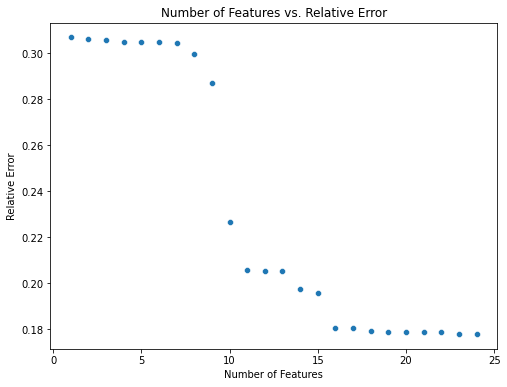

In [14]:
num_features = [i for i in range(1, len(errs) + 1)]
plotdf = pd.DataFrame({"Number of Features": num_features, "Relative Error": errs})
plt.figure(figsize = (8,6))
sns.scatterplot(data=plotdf, x="Number of Features", y="Relative Error")
plt.title("Number of Features vs. Relative Error")
plt.show()


In [ ]:
"""
X: ndarray
y: ndarray
"""
from numpy.linalg import norm, lstsq
def predict(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    v = lstsq(X_train, y_train, rcond=None)[0] 
    train_error = norm(X_train @ v - y_train) / norm(y_train)
    test_error = norm(X_test @ v - y_test) / norm(y_test)
    return v, train_error, test_error

def get_feature_importance(cleaned, estimator):
    features = []
    train_errs = []
    test_errs = []
    X = cleaned.drop(columns=['wl'])
    y = pd.DataFrame(cleaned['wl'])
    predictor_cols = X.columns
    X_train, X_test, y_train, y_test = train_test_split(X.to_numpy(), y.to_numpy(), test_size=0.2, random_state=42)
    for i in range(1, len(predictor_cols) + 1):
        selector = RFE(estimator, n_features_to_select=i)
        selector = selector.fit(X_train, y_train)
        desired_cols = []
        for i, feat in enumerate(selector.support_):
            if feat:
                desired_cols.append(predictor_cols[i])
        features.append(desired_cols)
        X_train_reduced = X_train[:, selector.support_]
        v_reduced = lstsq(X_train_reduced, y_train, rcond=None)[0]    
        train_error = norm(X_train_reduced @ v_reduced- y_train) / norm(y_train)
        X_test_reduced = X_test[:, selector.support_]
        test_error = norm(X_test_reduced @ v_reduced - y_test) / norm(y_test)
        train_errs.append(train_error)
        test_errs.append(test_error)

    return features, train_errs, test_errs
    

In [17]:
v, train_error, test_error = predict(cleaned.drop(columns=['wl']).to_numpy(), pd.DataFrame(cleaned['wl']).to_numpy())

In [18]:
def plot_residuals(y_true, y_pred, title="Residual Distribution"):
    residuals = y_true - y_pred
    plt.figure(figsize=(8, 6))
    sns.histplot(residuals, kde=True, bins=30, color='blue')
    plt.title(title)
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.tight_layout()
    plt.show()

In [19]:
print(train_error)
print(test_error)

0.17613803762858812
0.1911036887305553


In [ ]:
features, train_errs, test_errs = get_feature_importance(cleaned, LinearRegression())

In [21]:
print(features)
print(train_errs)
print(test_errs)
features[-1]

[['opp_fg_percent'], ['opp_fg_percent', 'opp_x3p_percent'], ['opp_ft_fga', 'opp_fg_percent', 'opp_x3p_percent'], ['opp_e_fg_percent', 'opp_ft_fga', 'opp_fg_percent', 'opp_x3p_percent'], ['opp_e_fg_percent', 'opp_ft_fga', 'opp_fg_percent', 'opp_x3p_percent', 'opp_x2p_percent'], ['opp_e_fg_percent', 'opp_ft_fga', 'opp_fg_per_game', 'opp_fg_percent', 'opp_x3p_percent', 'opp_x2p_percent'], ['opp_e_fg_percent', 'opp_ft_fga', 'opp_fg_per_game', 'opp_fg_percent', 'opp_x3p_percent', 'opp_x2p_percent', 'opp_pts_per_game'], ['opp_e_fg_percent', 'opp_ft_fga', 'opp_fg_per_game', 'opp_fg_percent', 'opp_x3p_percent', 'opp_x2p_percent', 'opp_orb_per_game', 'opp_pts_per_game'], ['opp_e_fg_percent', 'opp_ft_fga', 'opp_fg_per_game', 'opp_fg_percent', 'opp_x3p_percent', 'opp_x2p_percent', 'opp_orb_per_game', 'opp_tov_per_game', 'opp_pts_per_game'], ['d_rtg', 'opp_e_fg_percent', 'opp_ft_fga', 'opp_fg_per_game', 'opp_fg_percent', 'opp_x3p_percent', 'opp_x2p_percent', 'opp_orb_per_game', 'opp_tov_per_game',

['season',
 'age',
 'd_rtg',
 'pace',
 'opp_e_fg_percent',
 'opp_tov_percent',
 'opp_ft_fga',
 'drb_per_game',
 'stl_per_game',
 'blk_per_game',
 'pf_per_game',
 'opp_fg_per_game',
 'opp_fg_percent',
 'opp_x3p_per_game',
 'opp_x3p_percent',
 'opp_x2p_per_game',
 'opp_x2p_percent',
 'opp_ft_per_game',
 'opp_fta_per_game',
 'opp_orb_per_game',
 'opp_ast_per_game',
 'opp_tov_per_game',
 'opp_pts_per_game']

In [71]:
def plot_errors(errs, title):
    num_features = [i for i in range(1, len(errs) + 1)]
    plotdf = pd.DataFrame({"Number of Features": num_features, "Relative Error": errs})
    plt.figure(figsize = (8,6))
    sns.scatterplot(data=plotdf, x="Number of Features", y="Relative Error")
    plt.title(title)
    plt.show()

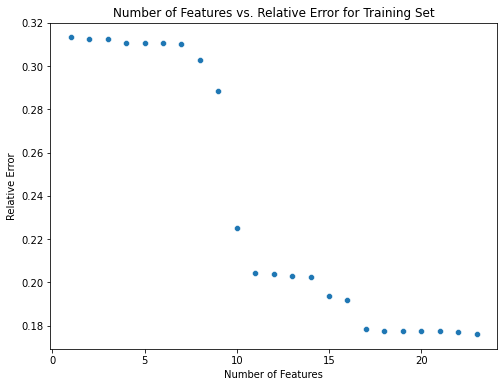

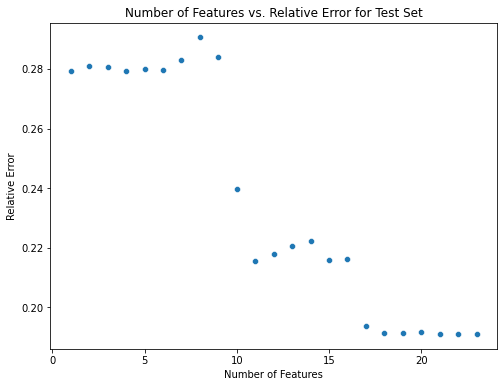

{'opp_tov_per_game', 'opp_x2p_percent', 'opp_ft_fga', 'opp_pts_per_game', 'opp_fg_percent', 'opp_e_fg_percent', 'opp_x3p_percent', 'opp_fg_per_game', 'opp_orb_per_game'}
{'opp_tov_per_game', 'opp_x2p_percent', 'd_rtg', 'opp_ft_fga', 'opp_pts_per_game', 'opp_fg_percent', 'opp_e_fg_percent', 'opp_x3p_percent', 'opp_fg_per_game', 'opp_orb_per_game'}


In [ ]:
plot_errors(train_errs, "Number of Features vs. Relative Error for Training Set")
plot_errors(test_errs, "Number of Features vs. Relative Error for Test Set")


In [ ]:
print(set(features[9]))
print(set(features[10]))
print(train_errs[9])
print(train_errs[10])
# opp_fg_percent

# drb_per_game
# age


{'opp_ft_fga', 'opp_x2p_percent', 'opp_fg_percent', 'opp_x3p_percent', 'd_rtg', 'opp_e_fg_percent', 'opp_tov_per_game', 'opp_pts_per_game', 'opp_orb_per_game', 'opp_fg_per_game'}
{'opp_ft_fga', 'opp_x2p_percent', 'opp_fg_percent', 'opp_x3p_percent', 'drb_per_game', 'd_rtg', 'opp_e_fg_percent', 'opp_tov_per_game', 'opp_pts_per_game', 'opp_orb_per_game', 'opp_fg_per_game'}
0.2249901488842574
0.20410910845421568


In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold

def predict_ridge(X, y):
    # Data
    # Define custom cross-validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # RidgeCV with manual CV split
    alphas = np.logspace(-4, 4, 50)
    model = RidgeCV(alphas=alphas, cv=cv, fit_intercept=False)
    model.fit(X, y)
    v = model.coef_.T
    print(v.shape)
    train_error = norm(X @ v - y) / norm(y)
  
    # Output
    return v, model.alpha_, train_error

In [23]:
feat = features[-1]

In [42]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
def feature_regression(X, y):
    # Generate synthetic regression data
    # Convert to DataFrame for correlation plotting

    # Standardize features
    df = pd.DataFrame(X, columns=X.columns)
    df['wl'] = y
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit linear regression
    model = LinearRegression()
    model.fit(X_scaled, y)

    # Add model predictions to DataFrame

    # Compute correlation matrix
    correlation_matrix = df.corr()

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()



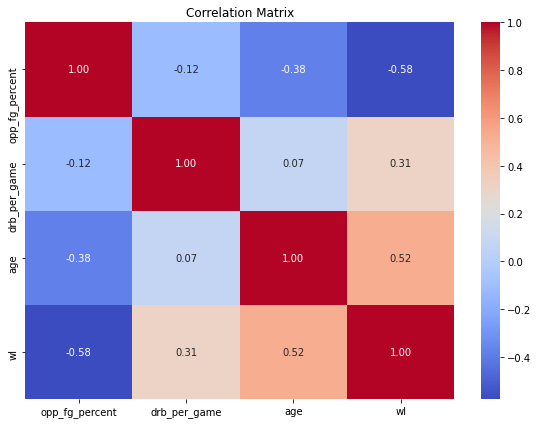

In [43]:
features = cleaned.drop(columns=['wl'])
features = features[['opp_fg_percent', 'drb_per_game', 'age']]
y = cleaned['wl']
feature_regression(features, y)

In [63]:
X = cleaned.drop(columns=['wl']).to_numpy()
y = pd.DataFrame(cleaned['wl']).to_numpy()
v, alpha, train_error = predict_ridge(X, y)
print(train_error)

(23, 1)
0.17803884177422258


In [69]:
alphas = np.logspace(-4, 4, 50)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
model = RidgeCV(alphas=alphas, cv=cv, fit_intercept=False)
features, train_errs, test_errs = get_feature_importance(cleaned, model)

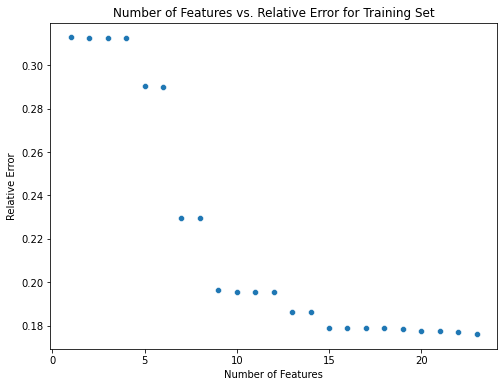

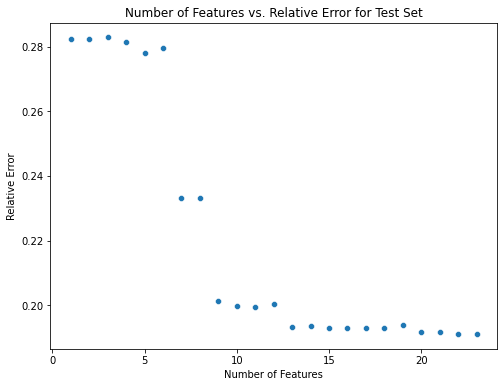

In [72]:
plot_errors(train_errs, "Number of Features vs. Relative Error for Training Set")
plot_errors(test_errs, "Number of Features vs. Relative Error for Test Set")


In [ ]:
print(features[11])
print(features[12])
print(alpha)
# alpha = 0.00030888435964774815
# 'opp_x3p_percent'
# 'd_rtg'
# 'age'
# 'opp_tov_per_game'

['age', 'd_rtg', 'opp_e_fg_percent', 'opp_tov_percent', 'opp_ft_fga', 'stl_per_game', 'opp_fg_percent', 'opp_x3p_percent', 'opp_x2p_percent', 'opp_ft_per_game', 'opp_orb_per_game', 'opp_tov_per_game']
['age', 'd_rtg', 'opp_e_fg_percent', 'opp_tov_percent', 'opp_ft_fga', 'stl_per_game', 'opp_fg_percent', 'opp_x3p_percent', 'opp_x2p_percent', 'opp_ft_per_game', 'opp_orb_per_game', 'opp_ast_per_game', 'opp_tov_per_game']
0.00030888435964774815


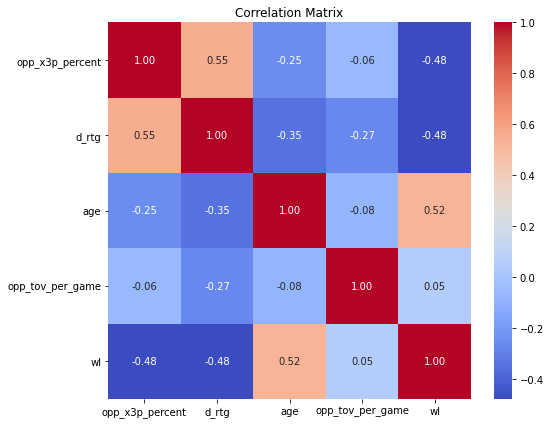

In [80]:
features = cleaned.drop(columns=['wl'])
features = features[['opp_x3p_percent', 'd_rtg', 'age', 'opp_tov_per_game']]
y = cleaned['wl']
feature_regression(features, y)